In [11]:
import time
import jax
import jax.numpy as jnp
import sparsejac
from jax.experimental import sparse
from uphate.uphate import get_phate_embedding, pdist_squared
import matplotlib.pyplot as plt
import phate.tree
import pandas as pd

In [5]:
X = jnp.load("../X_N500_D50_LNone_rev.npy")
J = jnp.load("../J_N500_D50_LNone_rev.npy")

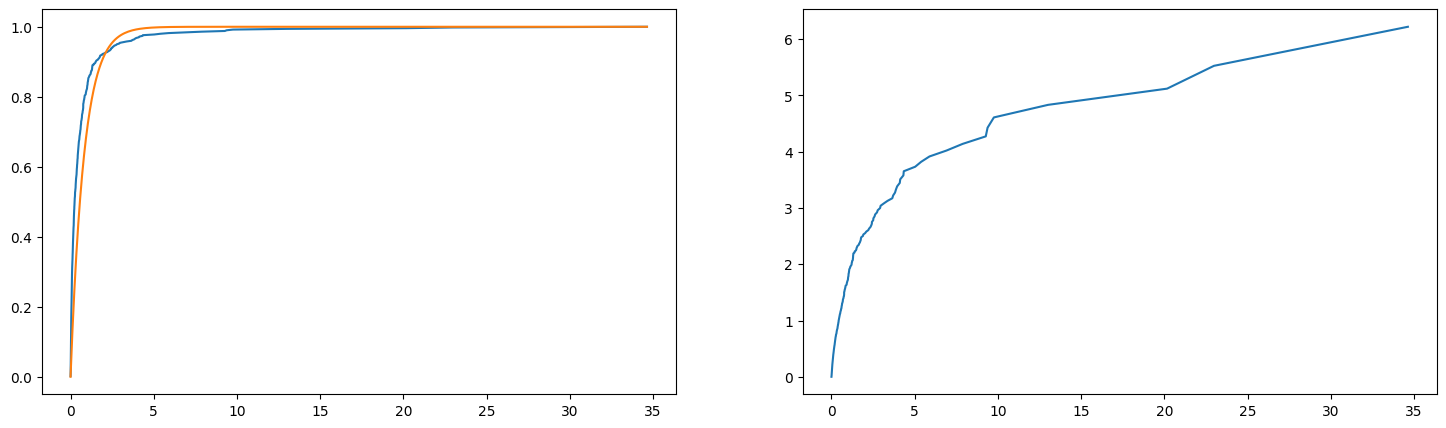

In [19]:
grad_magnitudes = jnp.linalg.norm(J[:, 0, :, :], axis=-1)
x = jnp.sort(grad_magnitudes[0])

y_cdf = jnp.arange(1, grad_magnitudes.shape[0] + 1) / grad_magnitudes.shape[0]
i_ranks = jnp.arange(1, grad_magnitudes.shape[0] + 1)
y_qq_plot = -jnp.log(1 - (i_ranks / (grad_magnitudes.shape[0] + 1)))

lambda_hat = 1.0 / jnp.mean(x)
scale_hat = 1.0 / lambda_hat # scale = 1/lambda

# 1. ECDF (Sample)
# The y-axis values are the cumulative probabilities (i/n)
y_ecdf = jnp.arange(1, grad_magnitudes.shape[0] + 1) / grad_magnitudes.shape[0]

# 2. Theoretical CDF
x_theoretical = jnp.linspace(0, x.max(), 300)
# F(x) = 1 - e^(-lambda * x)
y_theoretical = jax.scipy.stats.expon.cdf(x_theoretical, scale=scale_hat)

fig, ax = plt.subplots(1, 2, figsize=(18, 5))

ax[0].plot(x, y_ecdf)
ax[0].plot(x_theoretical, y_theoretical)
ax[1].plot(x, y_qq_plot)



In [32]:
(jnp.sort(grad_magnitudes, axis=1, descending=True).cumsum(axis=1) > 0 ).all()

Array(True, dtype=bool)

In [38]:
jnp.sort(grad_magnitudes, axis=1, descending=True).cumsum(axis=1)

Array([[  34.633293 ,   57.616276 ,   77.77971  , ...,  404.7274   ,
         404.72977  ,  404.73044  ],
       [  93.061356 ,  154.90933  ,  209.68019  , ..., 1051.74     ,
        1051.7487   , 1051.7559   ],
       [   2.992977 ,    5.835413 ,    8.311768 , ...,  133.49596  ,
         133.50111  ,  133.50327  ],
       ...,
       [   2.6231449,    4.809305 ,    6.7888274, ...,   69.01422  ,
          69.017494 ,   69.018295 ],
       [   8.0057125,   15.343912 ,   19.27775  , ...,   86.164444 ,
          86.16678  ,   86.167694 ],
       [   7.411682 ,   13.275211 ,   16.929905 , ...,   82.62969  ,
          82.63192  ,   82.63278  ]], dtype=float32)

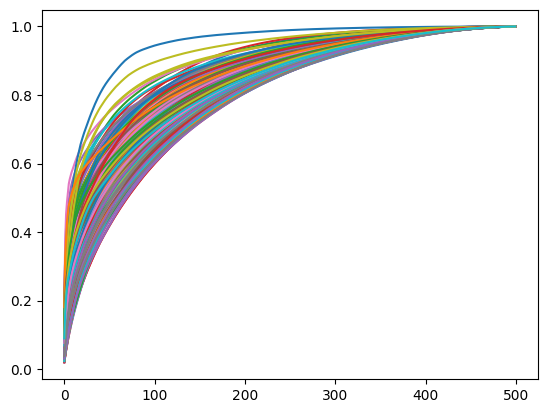

In [40]:
frac_of_total_grad = jnp.sort(grad_magnitudes, axis=1, descending=True).cumsum(axis=1) / jnp.sum(
    grad_magnitudes, axis=1, keepdims=True
)
for row in frac_of_total_grad:
    plt.plot(row)

In [236]:
def f(x):
    return jnp.sum(x) + jnp.concatenate((jnp.cumsum(x), jnp.cumsum(x)))


x = jnp.array([0.0, 0.0, 1.0])
y, vjp = jax.vjp(f, x)
J = jax.jacrev(f)(x)
(
    J,
    vjp(jnp.array([1.0, 0.0, 0.0, 0.0, 0.0, 0.0])),
    vjp(jnp.array([0.0, 0.0, 0.0, 0.0, 0.0, 1.0])),
)

(Array([[2., 1., 1.],
        [2., 2., 1.],
        [2., 2., 2.],
        [2., 1., 1.],
        [2., 2., 1.],
        [2., 2., 2.]], dtype=float32),
 (Array([2., 1., 1.], dtype=float32),),
 (Array([2., 2., 2.], dtype=float32),))

In [243]:
sparsity = sparse.BCOO.fromdense(jax.random.bernoulli(jax.random.PRNGKey(0), p=0.5, shape=J.shape))
sparse_J = sparsejac.jacrev(f, sparsity=sparsity)(x)
sparse_J.todense()

Array([[0., 0., 3.],
       [6., 0., 4.],
       [4., 0., 0.],
       [2., 0., 1.],
       [0., 0., 0.],
       [0., 0., 0.]], dtype=float32)

In [53]:
key = jax.random.PRNGKey(0)
n_samples, n_features = 100, 10
X = jax.random.normal(key, (n_samples, n_features))

print(
    f"Benchmarking Jacobian for N={n_samples}, D={n_features}"
)

# Warmup
print("Warmup...")
_ = get_phate_embedding(X, key, t=2, n_components=2)

# Define function to differentiate
def embedding_fn(x):
    return get_phate_embedding(x, key, t=2, n_components=2)

# Measure time
start_time = time.time()
J = jax.jit(jax.jacrev(embedding_fn))(X)
# Block until ready
J.block_until_ready()
end_time = time.time()

print(
    f"Jacobian shape: {J.shape}, Time taken: {end_time - start_time:.4f} seconds"
)

Benchmarking Jacobian for N=100, D=10
Warmup...
Jacobian shape: (100, 2, 100, 10), Time taken: 15.0306 seconds


In [ ]:
@jax.jit
def sparse_jacrev_fn(x):
  with jax.ensure_compile_time_eval():
    sparsity = sparse.BCOO.fromdense(jnp.eye(10000))
    jacrev_fn = sparsejac.jacrev(fn, sparsity=sparsity)
  return jacrev_fn(x)

In [ ]:
def knn_indices(X, k):
    pairwise_dist = pdist_squared(X)
    indices = jax.lax.top_k(-pairwise_dist, k=k + 1)[1]
    return indices

X = jax.random.normal(key, (n_samples, n_features))
indices = knn_indices(X, k=5)

In [ ]:
k = 5

pairwise_dist = pdist_squared(X)
values = -jax.lax.top_k(-pairwise_dist, k=5)[0][:, -1]
indices = jax.lax.top_k(-pairwise_dist, k=k + 1)[1]
sparse_pattern = sparse.BCOO.fromdense(jnp.where(pairwise_dist <= values[:, None], 1., 0.))